Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 

Warning message:
"il pacchetto 'ggplot2' è stato creato con R versione 4.4.3"


       RMSE   MAE
ARIMA 1.055 0.895
ETS   0.240 0.193
NNAR  0.998 0.813


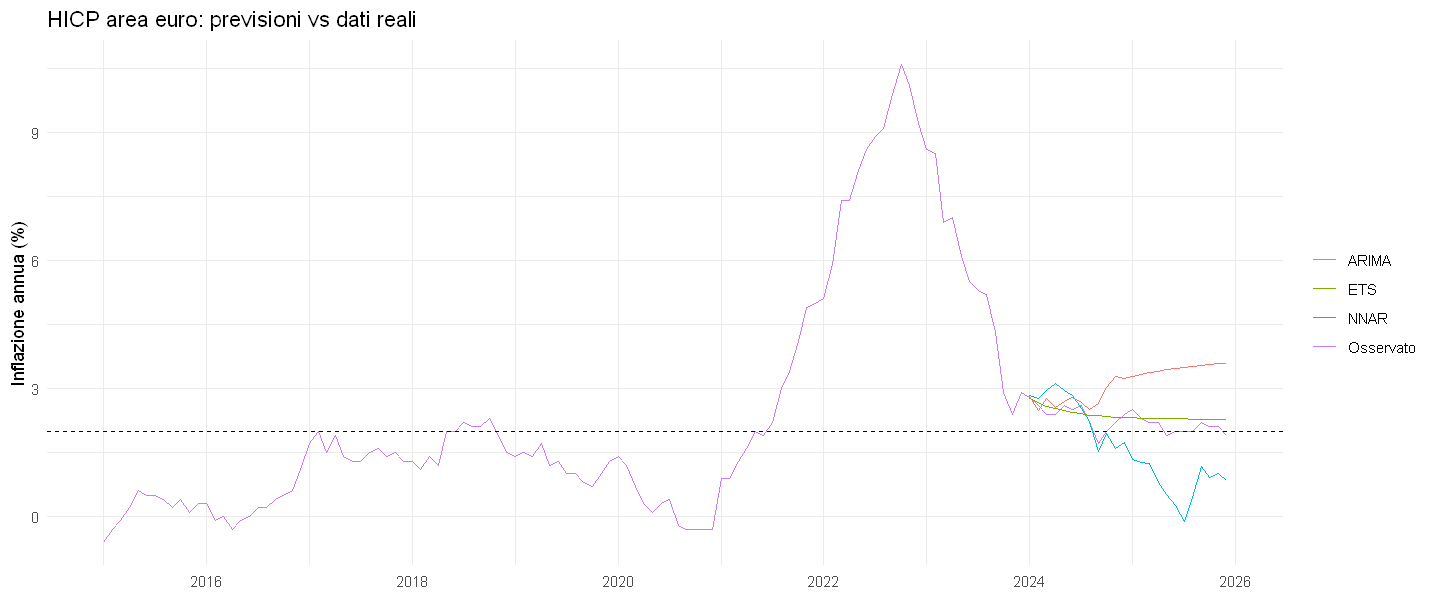

In [1]:

# Pacchetti necessari: install.packages(c("forecast", "ggplot2"))

library(forecast)
library(ggplot2)
options(repr.plot.width = 12, repr.plot.height = 5)   # grafici più larghi nel notebook

# 1. Dati: HICP area euro, variazione annua %, mensile
#    Fonte: ECB Data Portal (serie ICP.M.U2.N.000000.4.ANR)

url <- "https://data-api.ecb.europa.eu/service/data/ICP/M.U2.N.000000.4.ANR?format=csvdata"
raw <- read.csv(url)
raw <- raw[order(raw[["TIME_PERIOD"]]), c("TIME_PERIOD", "OBS_VALUE")]

# Trasformo in serie storica mensile (start = anno e mese della prima osservazione)
inizio <- as.numeric(strsplit(raw[["TIME_PERIOD"]][1], "-")[[1]])
y <- ts(raw[["OBS_VALUE"]], start = inizio, frequency = 12)


# 2. Train / test: gli ultimi 24 mesi fanno da test set

h <- 24
n <- length(y)
train <- window(y, end   = time(y)[n - h])
test  <- window(y, start = time(y)[n - h + 1])

# 3. Stima dei modelli (solo sul train)
set.seed(123)                  # la rete neurale ha una componente casuale
fit_arima <- auto.arima(train) # sceglie automaticamente p, d, q
fit_ets   <- ets(train)        # exponential smoothing, scelta automatica
fit_nn    <- nnetar(train)     # rete neurale con ritardi della serie come input

fc_arima <- forecast(fit_arima, h = h)
fc_ets   <- forecast(fit_ets,   h = h)
fc_nn    <- forecast(fit_nn,    h = h)


# 4. Confronto delle performance sul test set

risultati <- rbind(
  ARIMA = accuracy(fc_arima, test)["Test set", c("RMSE", "MAE")],
  ETS   = accuracy(fc_ets,   test)["Test set", c("RMSE", "MAE")],
  NNAR  = accuracy(fc_nn,    test)["Test set", c("RMSE", "MAE")]
)
print(round(risultati, 3))

# 5. Grafico: dati reali dal 2015 + previsioni dei tre modelli

autoplot(window(y, start = c(2015, 1)), series = "Osservato") +
  autolayer(fc_arima[["mean"]], series = "ARIMA") +
  autolayer(fc_ets[["mean"]],   series = "ETS") +
  autolayer(fc_nn[["mean"]],    series = "NNAR") +
  geom_hline(yintercept = 2, linetype = "dashed") +  # target BCE al 2%
  labs(title = "HICP area euro: previsioni vs dati reali",
       x = NULL, y = "Inflazione annua (%)", colour = NULL) +
  theme_minimal()